## **Medical Cost Personal Dataset**

## This dataset contains medical insurance cost information for 1338 individuals. It includes demographic and health-related variables such as age, sex, BMI, number of children, smoking status, and residential region in the US. The target variable is charges, which represents the medical insurance cost billed to the individual.

The dataset is commonly used for:

Regression modeling

Health economics research

Insurance pricing analysis

Machine learning education and tutorials

Columns

age: Age of primary beneficiary (int)

sex: Gender of beneficiary (male, female)

bmi: Body Mass Index, a measure of body fat based on height and weight (float)

children: Number of children covered by health insurance (int)

smoker: Smoking status of the beneficiary (yes, no)

region: Residential region in the US (northeast, northwest, southeast, southwest)

charges: Medical insurance cost billed to the beneficiary (float)

Potential Uses

Build predictive models for medical costs
Explore how smoking and BMI impact charges
Teach students about regression and feature engineering
Analyze healthcare affordability trends

## Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Find the MIssing Values

In [3]:

# 1. Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())
print("\n")

=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64




In [4]:
## The Statistic Summary

In [5]:
# 2. Summary Statistics
print("=== Summary Statistics ===")
print(df.describe())
print("\n")

=== Summary Statistics ===
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010




## *Visualization Method*

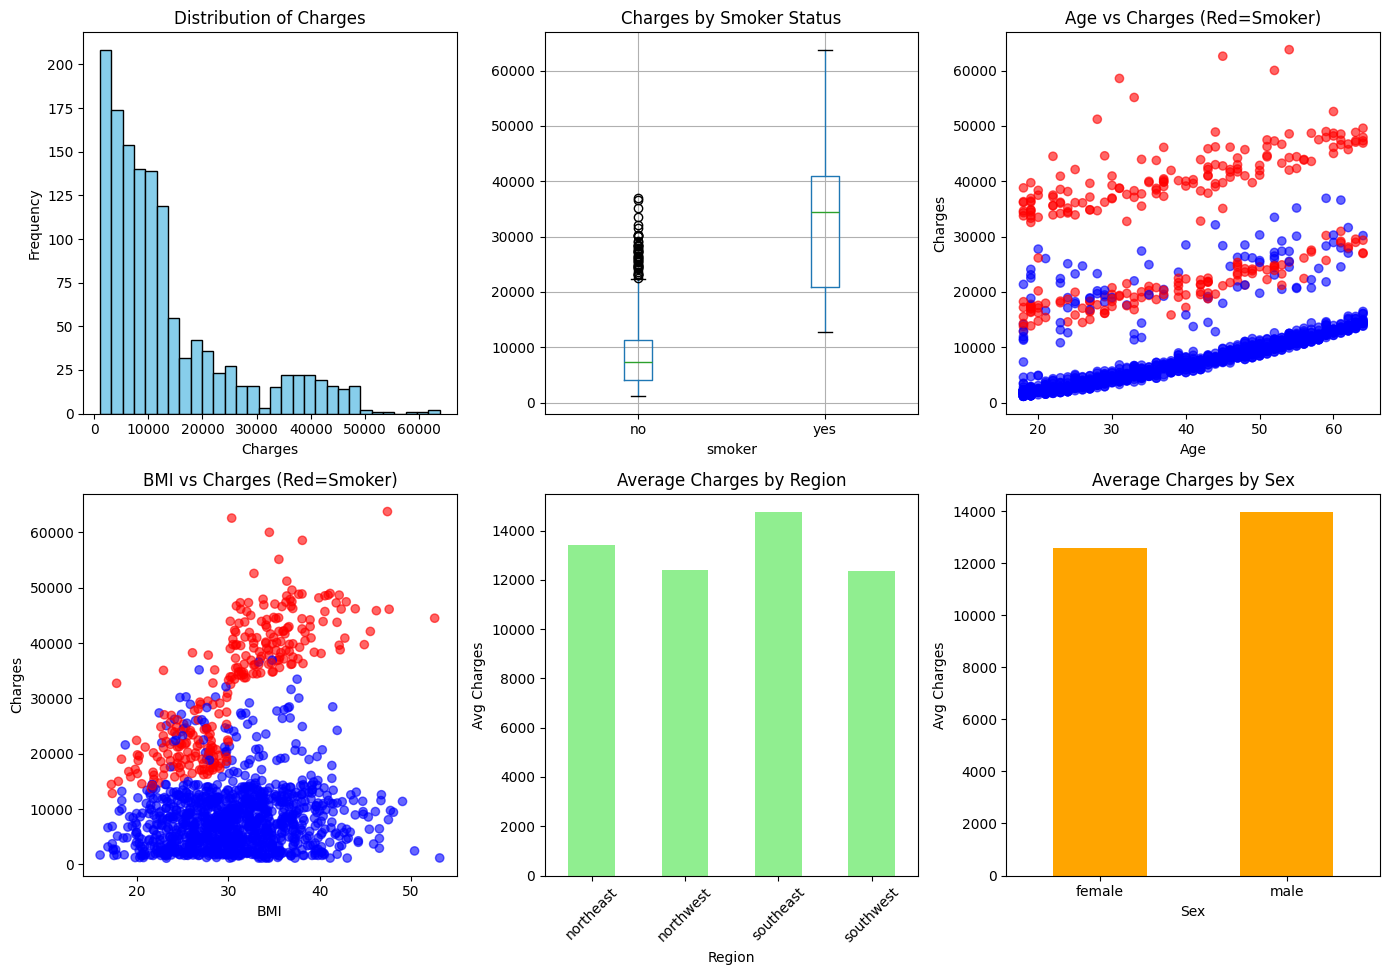

In [6]:

plt.figure(figsize=(14, 10))

# Histogram of charges
plt.subplot(2, 3, 1)
plt.hist(df['charges'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')

# Boxplot: Smoker vs Charges
plt.subplot(2, 3, 2)
df.boxplot(column='charges', by='smoker', ax=plt.gca())
plt.title('Charges by Smoker Status')
plt.suptitle('')  # Remove default title

# Scatter: Age vs Charges, colored by smoker
plt.subplot(2, 3, 3)
colors = df['smoker'].map({'yes': 'red', 'no': 'blue'})
plt.scatter(df['age'], df['charges'], c=colors, alpha=0.6)
plt.title('Age vs Charges (Red=Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges')

# Scatter: BMI vs Charges, colored by smoker
plt.subplot(2, 3, 4)
plt.scatter(df['bmi'], df['charges'], c=colors, alpha=0.6)
plt.title('BMI vs Charges (Red=Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges')

# Bar plot: Average charges by region
plt.subplot(2, 3, 5)
avg_by_region = df.groupby('region')['charges'].mean()
avg_by_region.plot(kind='bar', color='lightgreen')
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Avg Charges')
plt.xticks(rotation=45)

# Bar plot: Average charges by sex
plt.subplot(2, 3, 6)
avg_by_sex = df.groupby('sex')['charges'].mean()
avg_by_sex.plot(kind='bar', color='orange')
plt.title('Average Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Avg Charges')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## Hypothesis of the Values

In [8]:
from scipy import stats

In [9]:
 #5. Hypothesis Testing: Smokers vs Non-smokers
smoker_charges = df[df['smoker'] == 'yes']['charges']
non_smoker_charges = df[df['smoker'] == 'no']['charges']

t_stat, p_val = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)
print("=== Hypothesis Test: Smoker vs Non-Smoker Charges ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
if p_val < 0.001:
    print("Result: Highly significant difference (p < 0.001)")
print("\n")


=== Hypothesis Test: Smoker vs Non-Smoker Charges ===
T-statistic: 32.7519
P-value: 5.8895e-103
Result: Highly significant difference (p < 0.001)




## **MODELLING**

In [14]:

# 6. Data Modeling: Linear Regression

# Prepare features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Define preprocessor for categorical variables
categorical_features = ['sex', 'smoker', 'region']
numerical_features = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Fit preprocessor and transform
X_processed = preprocessor.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Linear Regression Results ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")

# Get feature names after encoding
feature_names = (
    numerical_features +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
)

# Display coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop 5 Features by Impact:")
print(coef_df.head())

=== Linear Regression Results ===
R² Score: 0.7836
RMSE: $5,796.28

Top 5 Features by Impact:
            Feature   Coefficient
4        smoker_yes  23651.128856
7  region_southwest   -809.799354
6  region_southeast   -657.864297
2          children    425.278784
5  region_northwest   -370.677326
